<a href="https://colab.research.google.com/github/cs10101/F1_race_winner_prediction_model/blob/main/F1_model_training_version_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading dataset

In [3]:
f1_data = pd.read_csv("f1_master_cleaned_with_winner_target.csv")

display(f1_data.tail())

display(f1_data.shape)

,season,round,race_name,team,grid_position,driver_code,participated_in_qualifying,reached_q2,reached_q3,model_q1_seconds,model_q2_seconds,model_q3_seconds,best_valid_quali_time,quali_position_numeric,pole_time_seconds,gap_to_pole_pct_model,is_winner
3591,2026,9,British Grand Prix,Aston Martin,21.0,ALO,1,0,0,93.025,999.990,999.990,93.025,22,88.111,0.055771,0
3592,2026,9,British Grand Prix,Aston Martin,22.0,STR,1,0,0,92.863,999.990,999.990,92.863,21,88.111,0.053932,0
3593,2026,9,British Grand Prix,Red Bull,7.0,VER,1,1,1,89.549,89.113,88.893,88.893,7,88.111,0.008875,0
3594,2026,9,British Grand Prix,Williams,16.0,ALB,1,1,0,90.638,91.341,999.990,90.638,16,88.111,0.028680,0
3595,2026,9,British Grand Prix,Audi,12.0,HUL,1,1,0,89.539,90.076,999.990,89.539,13,88.111,0.016207,0


(3596, 17)

In [4]:
display(f1_data.info())

display(f1_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3596 entries, 0 to 3595
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   season                      3596 non-null   int64  
 1   round                       3596 non-null   int64  
 2   race_name                   3596 non-null   object 
 3   team                        3596 non-null   object 
 4   grid_position               3596 non-null   float64
 5   driver_code                 3596 non-null   object 
 6   participated_in_qualifying  3596 non-null   int64  
 7   reached_q2                  3596 non-null   int64  
 8   reached_q3                  3596 non-null   int64  
 9   model_q1_seconds            3596 non-null   float64
 10  model_q2_seconds            3596 non-null   float64
 11  model_q3_seconds            3596 non-null   float64
 12  best_valid_quali_time       3596 non-null   float64
 13  quali_position_numeric      3596 

None

,season,round,grid_position,participated_in_qualifying,reached_q2,reached_q3,model_q1_seconds,model_q2_seconds,model_q3_seconds,best_valid_quali_time,quali_position_numeric,pole_time_seconds,gap_to_pole_pct_model,is_winner
count,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000,3596.000000
mean,2021.879588,11.033927,10.333426,0.996941,0.742214,0.493882,96.997127,325.637696,554.953717,95.562846,10.571190,82.771496,0.025492,0.049778
std,2.476193,6.371788,5.841324,0.055231,0.437477,0.500032,104.654573,403.674114,457.984088,101.383619,5.837741,11.453901,0.063487,0.217515
min,2018.000000,1.000000,0.000000,0.000000,0.000000,0.000000,53.904000,53.647000,53.377000,53.377000,1.000000,53.377000,-0.010590,0.000000
25%,2020.000000,6.000000,5.000000,1.000000,0.000000,0.000000,76.252750,77.615500,84.462250,75.695500,6.000000,74.670000,0.007301,0.000000
50%,2022.000000,11.000000,10.000000,1.000000,1.000000,0.000000,84.340500,89.783500,999.990000,83.544500,11.000000,81.299000,0.015454,0.000000
75%,2024.000000,16.000000,15.000000,1.000000,1.000000,1.000000,92.958750,999.990000,999.990000,92.123500,16.000000,90.029000,0.024891,0.000000
max,2026.000000,24.000000,22.000000,1.000000,1.000000,1.000000,999.990000,999.990000,999.990000,999.990000,23.000000,116.559000,0.973319,1.000000


In [5]:
print(f1_data.isnull().sum())

season                        0
round                         0
race_name                     0
team                          0
grid_position                 0
driver_code                   0
participated_in_qualifying    0
reached_q2                    0
reached_q3                    0
model_q1_seconds              0
model_q2_seconds              0
model_q3_seconds              0
best_valid_quali_time         0
quali_position_numeric        0
pole_time_seconds             0
gap_to_pole_pct_model         0
is_winner                     0
dtype: int64


# defining training features

In [6]:
features = ["season", "round", "race_name", "team", "grid_position", "driver_code", "participated_in_qualifying",
            "reached_q2", "reached_q3", "model_q1_seconds", "model_q2_seconds", "model_q3_seconds", "best_valid_quali_time",
            "quali_position_numeric", "pole_time_seconds", "gap_to_pole_pct_model"]

### 1. Handle Categorical Features

I'll apply one-hot encoding to the categorical features: `race_name`, `team`, and `driver_code`. This converts them into a numerical format suitable for machine learning models. I will also make sure to use a copy of the dataframe to avoid `SettingWithCopyWarning`.

In [7]:
f1_data_processed = f1_data.copy()
categorical_features = ['race_name', 'team', 'driver_code']
f1_data_processed = pd.get_dummies(f1_data_processed, columns=categorical_features, drop_first=True)

display(f1_data_processed.head())

,season,round,grid_position,participated_in_qualifying,reached_q2,reached_q3,model_q1_seconds,model_q2_seconds,model_q3_seconds,best_valid_quali_time,...,driver_code_RUS,driver_code_SAI,driver_code_SAR,driver_code_SIR,driver_code_STR,driver_code_TSU,driver_code_VAN,driver_code_VER,driver_code_VET,driver_code_ZHO
0,2018,1,3.0,1,1,1,83.348,81.944,81.838,81.838,...,False,False,False,False,False,False,False,False,True,False
1,2018,1,1.0,1,1,1,82.824,82.051,81.164,81.164,...,False,False,False,False,False,False,False,False,False,False
2,2018,1,2.0,1,1,1,83.096,82.507,81.828,81.828,...,False,False,False,False,False,False,False,False,False,False
3,2018,1,8.0,1,1,1,83.494,82.897,82.152,82.152,...,False,False,False,False,False,False,False,False,False,False
4,2018,1,10.0,1,1,0,83.597,83.692,999.990,83.597,...,False,False,False,False,False,False,False,False,False,False


### 2. Split Data into Training and Test Sets

Now, I'll divide the preprocessed dataset into training and testing sets, using `is_winner` as the target variable. This prepares the data for model training and evaluation. I'll use `train_test_split` from `sklearn.model_selection`.

In [8]:
from sklearn.model_selection import train_test_split

X = f1_data_processed.drop('is_winner', axis=1)
y = f1_data_processed['is_winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2876, 119)
X_test shape: (720, 119)
y_train shape: (2876,)
y_test shape: (720,)


### 3. Train a Classification Model (XGBoost)

Next, I'll train an XGBoost Classifier model on the training data to predict the `is_winner` target variable.

In [9]:
import xgboost as xgb

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # Binary classification
    eval_metric='logloss',        # Evaluation metric for binary classification
    use_label_encoder=False,      # Suppress warning for label encoder
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:14:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.


### 4. Evaluate Model Performance

Finally, I'll evaluate the trained XGBoost model's performance on the test set. I'll use a classification report to show accuracy, precision, recall, and F1-score, and a confusion matrix to visualize the model's predictions.

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       684
           1       0.60      0.33      0.43        36

    accuracy                           0.96       720
   macro avg       0.78      0.66      0.70       720
weighted avg       0.95      0.96      0.95       720


Accuracy: 0.9556


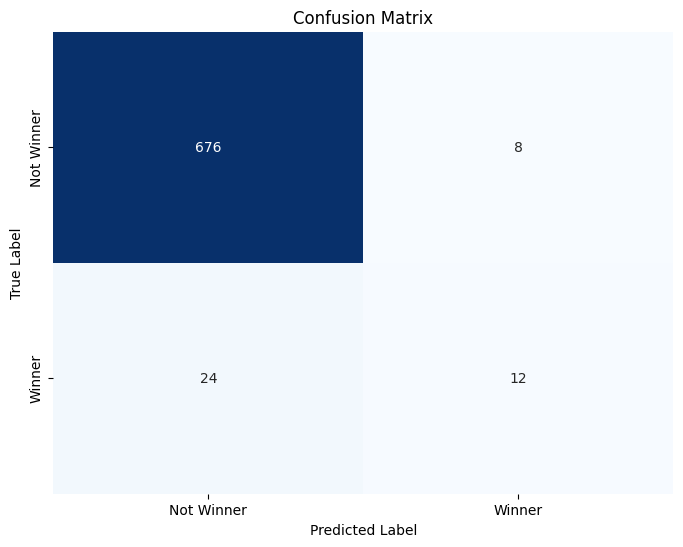

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Winner', 'Winner'],
            yticklabels=['Not Winner', 'Winner'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5. Summary and Next Steps

The initial XGBoost model has been trained and evaluated. Here's a brief summary of the performance:

*   **Accuracy**: The overall accuracy of the model indicates how many predictions were correct out of all predictions.
*   **Precision**: For the 'Winner' class, precision tells us how many of the predicted winners were actually winners.
*   **Recall**: For the 'Winner' class, recall tells us how many of the actual winners were correctly identified by the model.
*   **F1-Score**: The F1-score is the harmonic mean of precision and recall, providing a balanced measure.

**Potential Next Steps for Improvement:**

1.  **Hyperparameter Tuning**: Experiment with different hyperparameters for the XGBoost model (e.g., `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`) using techniques like GridSearchCV or RandomizedSearchCV to find the optimal configuration.
2.  **Feature Engineering**: Create new features from existing ones that might capture more predictive power (e.g., historical performance of drivers/teams, average grid position, track specific statistics).
3.  **Cross-Validation**: Implement k-fold cross-validation during training to get a more robust estimate of the model's performance and reduce overfitting.
4.  **Feature Importance Analysis**: Analyze the feature importances from the trained XGBoost model to understand which features are most influential in predicting a winner. This can guide further feature selection or engineering efforts.
5.  **Ensemble Methods**: Explore other ensemble models like LightGBM, CatBoost, or even stacking multiple models for potentially better performance.
6.  **Anomaly Detection**: Investigate any races or drivers that are consistently misclassified to identify unique patterns or data issues.